In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [62]:
df = pd.read_csv('/home/lauryn/Documents/03_final_results/result.emapper.annotations', sep='\t', comment='#', header=None)

df.columns = [
    "Sequence_ID",
    "Seed_Ortholog",
    "E_value",
    "Score",
    "eggNOG_OGs",
    "Max_Annotation_Level",
    "COG_Category",
    "Function_Description",
    "Annotated_Gene_Name",
    "GO_Terms",
    "EC_Number",
    "KEGG_KO",
    "KEGG_Pathway",
    "KEGG_Module",
    "KEGG_Reaction",
    "KEGG_rClass",
    "KEGG_BRITE",
    "KEGG_TC",
    "CAZy",
    "BiGG_Reaction",
    "Pfam_Domains"
]
df.head()

,Sequence_ID,Seed_Ortholog,E_value,Score,eggNOG_OGs,Max_Annotation_Level,COG_Category,Function_Description,Annotated_Gene_Name,GO_Terms,...,KEGG_KO,KEGG_Pathway,KEGG_Module,KEGG_Reaction,KEGG_rClass,KEGG_BRITE,KEGG_TC,CAZy,BiGG_Reaction,Pfam_Domains
0,NODE_1_length_10227_cov_1653.476462_g0_i0,500633.CLOHIR_02084,9.65e-56,200.0,"arCOG05874@1|root,2ZJ01@2|Bacteria,1V450@1239|...",186801|Clostridia,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
1,NODE_2_length_10176_cov_22.743443_g1_i0,765869.BDW_07310,0.000972,54.3,"COG0729@1|root,COG2911@1|root,COG3210@1|root,C...",2|Bacteria,U,"domain, Protein",-,-,...,"ko:K13735,ko:K21449","ko05100,map05100",-,-,-,"ko00000,ko00001,ko02000",1.B.40.2,-,-,"Beta_helix,IAT_beta,Invasin_D3,PATR,Peptidase_S74"
2,NODE_3_length_10130_cov_1594.109476_g0_i1,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
3,NODE_5_length_10126_cov_1560.953148_g0_i3,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
4,NODE_6_length_10123_cov_1560.832637_g0_i4,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


### 📊 Description des colonnes du tableau d'annotation

| Colonne | Description |
|--------|-------------|
| `Sequence_ID` | Identifiant de la séquence soumise (transcrit ou protéine) |
| `Seed_Ortholog` | Orthologue utilisé pour transférer les annotations (meilleur hit) |
| `E_value` | Valeur E du meilleur alignement, reflétant la confiance de l’annotation |
| `Score` | Score brut de l'alignement |
| `eggNOG_OGs` | Groupes orthologues EggNOG (COG/arCOG/ENOG…) assignés |
| `Max_Annotation_Level` | Niveau taxonomique maximal d’où les annotations sont tirées (ex: Eukaryota, Bacteria...) |
| `COG_Category` | Catégorie(s) fonctionnelle(s) COG (ex: K = Transcription, G = Métabolisme...) |
| `Function_Description` | Description fonctionnelle du gène annoté |
| `Annotated_Gene_Name` | Nom du gène suggéré (si disponible) |
| `GO_Terms` | Termes Gene Ontology (GO) associés à la séquence |
| `EC_Number` | Numéro EC indiquant une activité enzymatique |
| `KEGG_KO` | Identifiant KEGG Orthology (KO) |
| `KEGG_Pathway` | Voies métaboliques KEGG associées |
| `KEGG_Module` | Modules KEGG (ensembles de gènes formant une unité fonctionnelle) |
| `KEGG_Reaction` | Réactions biochimiques KEGG |
| `KEGG_rClass` | Classes de réactions KEGG |
| `KEGG_BRITE` | Annotations hiérarchiques KEGG BRITE (classifications fonctionnelles) |
| `KEGG_TC` | Classification KEGG Transporter (TCDB) |
| `CAZy` | Famille d’enzymes de dégradation des glucides (Carbohydrate-Active enZymes) |
| `BiGG_Reaction` | Réactions métaboliques issues de la base BiGG Models |
| `Pfam_Domains` | Domaines protéiques annotés selon Pfam |



In [63]:
df = df.replace('-', pd.NA)
df

,Sequence_ID,Seed_Ortholog,E_value,Score,eggNOG_OGs,Max_Annotation_Level,COG_Category,Function_Description,Annotated_Gene_Name,GO_Terms,...,KEGG_KO,KEGG_Pathway,KEGG_Module,KEGG_Reaction,KEGG_rClass,KEGG_BRITE,KEGG_TC,CAZy,BiGG_Reaction,Pfam_Domains
0,NODE_1_length_10227_cov_1653.476462_g0_i0,500633.CLOHIR_02084,9.65e-56,200.0,"arCOG05874@1|root,2ZJ01@2|Bacteria,1V450@1239|...",186801|Clostridia,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,NODE_2_length_10176_cov_22.743443_g1_i0,765869.BDW_07310,0.000972,54.3,"COG0729@1|root,COG2911@1|root,COG3210@1|root,C...",2|Bacteria,U,"domain, Protein",<NA>,<NA>,...,"ko:K13735,ko:K21449","ko05100,map05100",<NA>,<NA>,<NA>,"ko00000,ko00001,ko02000",1.B.40.2,<NA>,<NA>,"Beta_helix,IAT_beta,Invasin_D3,PATR,Peptidase_S74"
2,NODE_3_length_10130_cov_1594.109476_g0_i1,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,NODE_5_length_10126_cov_1560.953148_g0_i3,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,NODE_6_length_10123_cov_1560.832637_g0_i4,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43711,NODE_166039_length_198_cov_4.264000_g160963_i0,7897.ENSLACP00000022995,2.19e-05,47.8,"COG0666@1|root,KOG4177@2759|Eukaryota,39RVT@33...",33208|Metazoa,M,Ankyrin repeat and EF-hand,ANKEF1,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Ank,Ank_2,Ank_3,Ank_4"
43712,NODE_166044_length_198_cov_4.208000_g160968_i0,411490.ANACAC_01115,2.5e-08,52.8,"2DPDN@1|root,331NP@2|Bacteria,1VFF8@1239|Firmi...",186801|Clostridia,S,ORF located using Blastx,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
43713,NODE_166458_length_196_cov_4.544715_g161382_i0,568703.LGG_00814,3.84e-14,68.2,"2DN97@1|root,32W7A@2|Bacteria,1VANB@1239|Firmi...",91061|Bacilli,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
43714,NODE_166474_length_196_cov_3.585366_g161398_i0,102107.XP_008221921.1,2.09e-05,47.8,"2CN1U@1|root,2QTDN@2759|Eukaryota,37KT5@33090|...",35493|Streptophyta,S,Armadillo repeat only,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Arm


In [64]:
print(f"Nombre total de transcrits : {len(df)}\n")
for col in df.columns:
    if col in ["eggNOG_OGs","GO_Terms","KEGG_KO","BIGG_Reaction","Pfam_Domains"]:
        print(f"Pour {col} : ")
        print (f"Transcrits annotés : {df[col].notna().sum()} soit {df[col].notna().sum() * 100 / len(df[col]):.2f}% ")
        print(f"Annotations uniques : {len(df[col].dropna().unique())} soit {len(df[col].dropna().unique()) * 100 / len(df[col]):.2f}% \n")


Nombre total de transcrits : 43716

Pour eggNOG_OGs : 
Transcrits annotés : 43716 soit 100.00% 
Annotations uniques : 23564 soit 53.90% 

Pour GO_Terms : 
Transcrits annotés : 13166 soit 30.12% 
Annotations uniques : 5779 soit 13.22% 

Pour KEGG_KO : 
Transcrits annotés : 23297 soit 53.29% 
Annotations uniques : 6240 soit 14.27% 

Pour Pfam_Domains : 
Transcrits annotés : 39141 soit 89.53% 
Annotations uniques : 6864 soit 15.70% 



go-basic.obo: fmt(1.2) rel(2025-06-01) 43,448 Terms


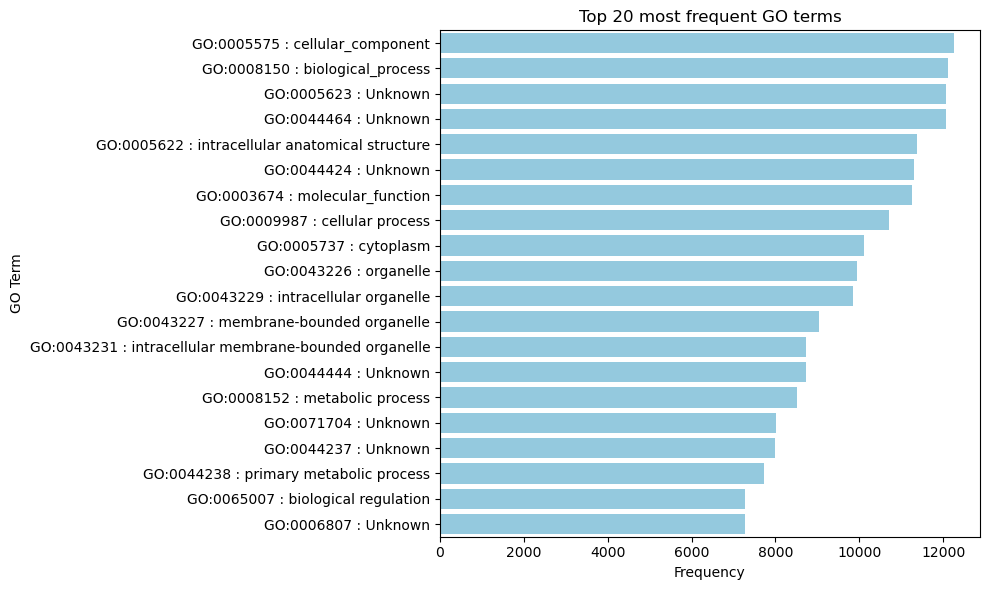

In [65]:
from collections import Counter
from goatools.obo_parser import GODag
import os
import urllib.request

# Télécharger le fichier go-basic.obo si nécessaire
obo_url = "http://geneontology.org/ontology/go-basic.obo"
obo_path = "go-basic.obo"
if not os.path.exists(obo_path):
    print("Downloading go-basic.obo...")
    urllib.request.urlretrieve(obo_url, obo_path)

# Charger l'ontologie GO
go_dag = GODag(obo_path)

# Compter les GO terms
go_terms = df['GO_Terms'].dropna().str.cat(sep=',').split(',')
go_counts = Counter(go_terms)

# Prendre les 20 plus fréquents
most_common_go = go_counts.most_common(20)

# Extraire les noms GO (en gérant les cas où le GO ID n'existe pas dans le DAG)
labels = []
values = []
for go_id, count in most_common_go:
    try:
        label = f"{go_id} : {go_dag[go_id].name}"
    except KeyError:
        label = f"{go_id} : Unknown"
    labels.append(label)
    values.append(count)

# Tracer le barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=values, y=labels, color='skyblue')
plt.title('Top 20 most frequent GO terms')
plt.xlabel('Frequency')
plt.ylabel('GO Term')
plt.tight_layout()
plt.show()


INFORMATION STORAGE AND PROCESSING

- **J** Translation, ribosomal structure and biogenesis
- **A** RNA processing and modification
- **K** Transcription
- **L** Replication, recombination and repair
- **B** Chromatin structure and dynamics

CELLULAR PROCESSES AND SIGNALING

- **D** Cell cycle control, cell division, chromosome partitioning
- **Y** Nuclear structure
- **V** Defense mechanisms
- **T** Signal transduction mechanisms
- **M** Cell wall/membrane/envelope biogenesis
- **N** Cell motility
- **Z** Cytoskeleton
- **W** Extracellular structures
- **U** Intracellular trafficking, secretion, and vesicular transport
- **O** Posttranslational modification, protein turnover, chaperones

METABOLISM

- **C** Energy production and conversion
- **G** Carbohydrate transport and metabolism
- **E** Amino acid transport and metabolism
- **F** Nucleotide transport and metabolism
- **H** Coenzyme transport and metabolism
- **I** Lipid transport and metabolism
- **P** Inorganic ion transport and metabolism
- **Q** Secondary metabolites biosynthesis, transport and catabolism

POORLY CHARACTERIZED

- **R** General function prediction only
- **S** Function unknown

In [66]:
# Dictionnaire de correspondance code -> fonction
cog_functions = {
    'J': 'Translation, ribosomal structure and biogenesis',
    'A': 'RNA processing and modification',
    'K': 'Transcription',
    'L': 'Replication, recombination and repair',
    'B': 'Chromatin structure and dynamics',
    'D': 'Cell cycle control, cell division, chromosome partitioning',
    'Y': 'Nuclear structure',
    'V': 'Defense mechanisms',
    'T': 'Signal transduction mechanisms',
    'M': 'Cell wall/membrane/envelope biogenesis',
    'N': 'Cell motility',
    'Z': 'Cytoskeleton',
    'W': 'Extracellular structures',
    'U': 'Intracellular trafficking, secretion, and vesicular transport',
    'O': 'Posttranslational modification, protein turnover, chaperones',
    'C': 'Energy production and conversion',
    'G': 'Carbohydrate transport and metabolism',
    'E': 'Amino acid transport and metabolism',
    'F': 'Nucleotide transport and metabolism',
    'H': 'Coenzyme transport and metabolism',
    'I': 'Lipid transport and metabolism',
    'P': 'Inorganic ion transport and metabolism',
    'Q': 'Secondary metabolites biosynthesis, transport and catabolism',
    'R': 'General function prediction only',
    'S': 'Function unknown'
}

# Dictionnaire de correspondance code -> grande catégorie
cog_categories = {
    'J': 'INFORMATION STORAGE AND PROCESSING',
    'A': 'INFORMATION STORAGE AND PROCESSING',
    'K': 'INFORMATION STORAGE AND PROCESSING',
    'L': 'INFORMATION STORAGE AND PROCESSING',
    'B': 'INFORMATION STORAGE AND PROCESSING',
    'D': 'CELLULAR PROCESSES AND SIGNALING',
    'Y': 'CELLULAR PROCESSES AND SIGNALING',
    'V': 'CELLULAR PROCESSES AND SIGNALING',
    'T': 'CELLULAR PROCESSES AND SIGNALING',
    'M': 'CELLULAR PROCESSES AND SIGNALING',
    'N': 'CELLULAR PROCESSES AND SIGNALING',
    'Z': 'CELLULAR PROCESSES AND SIGNALING',
    'W': 'CELLULAR PROCESSES AND SIGNALING',
    'U': 'CELLULAR PROCESSES AND SIGNALING',
    'O': 'CELLULAR PROCESSES AND SIGNALING',
    'C': 'METABOLISM',
    'G': 'METABOLISM',
    'E': 'METABOLISM',
    'F': 'METABOLISM',
    'H': 'METABOLISM',
    'I': 'METABOLISM',
    'P': 'METABOLISM',
    'Q': 'METABOLISM',
    'R': 'POORLY CHARACTERIZED',
    'S': 'POORLY CHARACTERIZED'
}

# Ajout des colonnes

# 1. Extraire la première lettre du/des code(s) COG (certaines cellules peuvent contenir plusieurs codes, ex: "K,L")
df['COG_code'] = df['COG_Category'].str[0]  # Prend la première lettre (ou NaN si vide)

# 2. Mapper la fonction COG
df['COG_Function'] = df['COG_code'].map(cog_functions)

# 3. Mapper la grande catégorie
df['COG_Category'] = df['COG_code'].map(cog_categories)

columns = list(df.columns)
columns.insert(columns.index('COG_Category'), columns.pop(columns.index('COG_Function')))
df = df[columns]

df

,Sequence_ID,Seed_Ortholog,E_value,Score,eggNOG_OGs,Max_Annotation_Level,COG_Function,COG_Category,Function_Description,Annotated_Gene_Name,...,KEGG_Pathway,KEGG_Module,KEGG_Reaction,KEGG_rClass,KEGG_BRITE,KEGG_TC,CAZy,BiGG_Reaction,Pfam_Domains,COG_code
0,NODE_1_length_10227_cov_1653.476462_g0_i0,500633.CLOHIR_02084,9.65e-56,200.0,"arCOG05874@1|root,2ZJ01@2|Bacteria,1V450@1239|...",186801|Clostridia,NaN,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,NODE_2_length_10176_cov_22.743443_g1_i0,765869.BDW_07310,0.000972,54.3,"COG0729@1|root,COG2911@1|root,COG3210@1|root,C...",2|Bacteria,"Intracellular trafficking, secretion, and vesi...",CELLULAR PROCESSES AND SIGNALING,"domain, Protein",<NA>,...,"ko05100,map05100",<NA>,<NA>,<NA>,"ko00000,ko00001,ko02000",1.B.40.2,<NA>,<NA>,"Beta_helix,IAT_beta,Invasin_D3,PATR,Peptidase_S74",U
2,NODE_3_length_10130_cov_1594.109476_g0_i1,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,NaN,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,NODE_5_length_10126_cov_1560.953148_g0_i3,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,NaN,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,NODE_6_length_10123_cov_1560.832637_g0_i4,1430440.MGMSRv2_1983,1.24e-58,212.0,"2DNPH@1|root,32YF1@2|Bacteria,1NARM@1224|Prote...",28211|Alphaproteobacteria,NaN,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43711,NODE_166039_length_198_cov_4.264000_g160963_i0,7897.ENSLACP00000022995,2.19e-05,47.8,"COG0666@1|root,KOG4177@2759|Eukaryota,39RVT@33...",33208|Metazoa,Cell wall/membrane/envelope biogenesis,CELLULAR PROCESSES AND SIGNALING,Ankyrin repeat and EF-hand,ANKEF1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Ank,Ank_2,Ank_3,Ank_4",M
43712,NODE_166044_length_198_cov_4.208000_g160968_i0,411490.ANACAC_01115,2.5e-08,52.8,"2DPDN@1|root,331NP@2|Bacteria,1VFF8@1239|Firmi...",186801|Clostridia,Function unknown,POORLY CHARACTERIZED,ORF located using Blastx,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,S
43713,NODE_166458_length_196_cov_4.544715_g161382_i0,568703.LGG_00814,3.84e-14,68.2,"2DN97@1|root,32W7A@2|Bacteria,1VANB@1239|Firmi...",91061|Bacilli,NaN,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
43714,NODE_166474_length_196_cov_3.585366_g161398_i0,102107.XP_008221921.1,2.09e-05,47.8,"2CN1U@1|root,2QTDN@2759|Eukaryota,37KT5@33090|...",35493|Streptophyta,Function unknown,POORLY CHARACTERIZED,Armadillo repeat only,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Arm,S


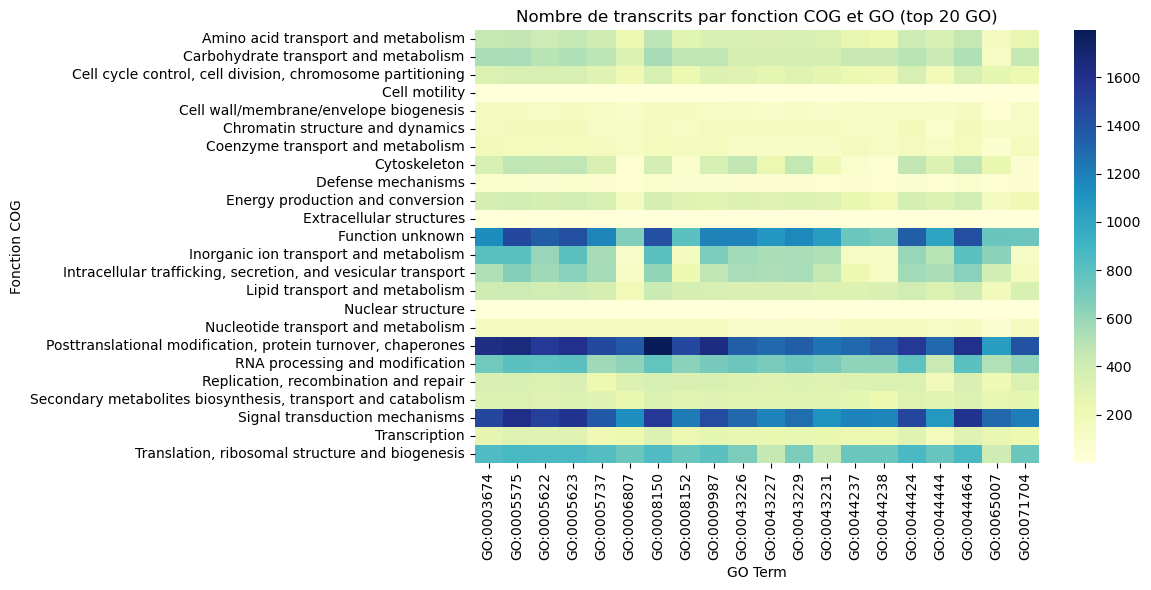

In [67]:
# Explode GO_Terms so each GO term is a separate row
df_exploded = df.dropna(subset=['GO_Terms']).copy()
df_exploded['GO_Term'] = df_exploded['GO_Terms'].str.split(',')  # split GO terms
df_exploded = df_exploded.explode('GO_Term')

# Create a pivot table for the top N GO terms (to keep the heatmap readable)
top_go = df_exploded['GO_Term'].value_counts().head(20).index  # top 20 GO terms
pivot = pd.pivot_table(
    df_exploded[df_exploded['GO_Term'].isin(top_go)],
    index='COG_Function',
    columns='GO_Term',
    aggfunc='size',
    fill_value=0
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Nombre de transcrits par fonction COG et GO (top 20 GO)")
plt.ylabel("Fonction COG")
plt.xlabel("GO Term")
plt.tight_layout()
plt.show()

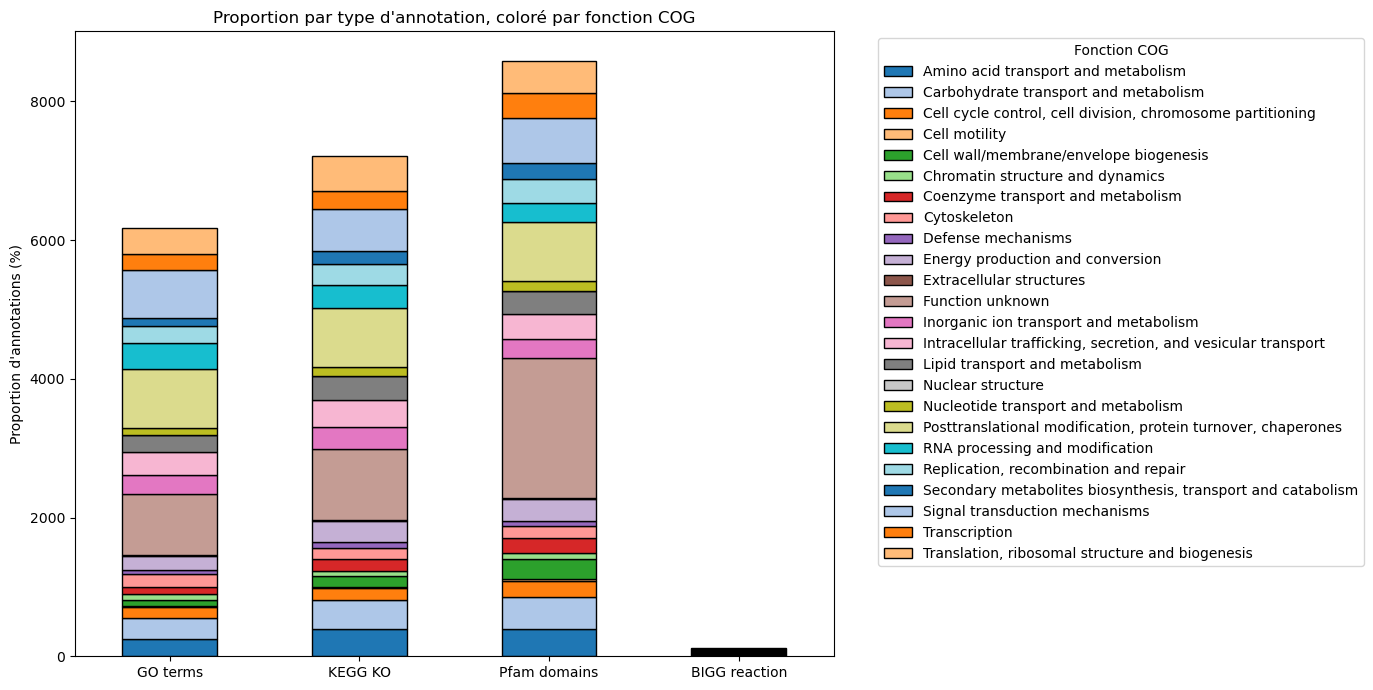

In [ ]:

# Nombre de GO par fonction COG
go_counts_by_cog = df.groupby('COG_Function')['GO_Terms'].nunique()

# Nombre de KEGG KO par fonction COG
kegg_counts_by_cog = df.groupby('COG_Function')['KEGG_KO'].nunique()

# Nombre de Pfam par fonction COG
pfam_counts_by_cog = df.groupby('COG_Function')['Pfam_Domains'].nunique()

# Nombre de Pfam par fonction COG
bigg_counts_by_cog = df.groupby('COG_Function')['BiGG_Reaction'].nunique()

# Fusionner dans un seul DataFrame pour affichage
summary = pd.DataFrame({
    'GO terms': go_counts_by_cog,
    'KEGG KO': kegg_counts_by_cog,
    'Pfam domains': pfam_counts_by_cog,
    'BIGG reaction': bigg_counts_by_cog
}).fillna(0).astype(int)

# Calculer la proportion par fonction COG (chaque ligne = 100%)
summary_prop = summary.div(summary.sum(axis=1), axis=0) * 100

# Transposer pour affichage groupé
summary_prop_T = summary_prop.transpose()

# Tracer le barplot groupé
colors = plt.cm.tab20.colors
summary_prop_T.plot(kind='bar', figsize=(14, 7), color=colors, edgecolor='black', stacked=True)

plt.ylabel("Proportion d'annotations (%)")
plt.title("Proportion par type d'annotation (somme par fonction COG = 100%)")
plt.xticks(rotation=0)
plt.legend(title="Fonction COG", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
